#Problem Statement
Accurate histopathologic cancer detection based on scan images is critical because it directly impacts early diagnosis, treatment planning, and patient survival. Studies show that cancer remains one of the leading causes of death worldwide. Just i**n the United States**, according to National Center for Health Statistics, **2,041,910 new cancer cases and 618,120 cancer deaths** are projected to occur **in 2025**. Errors in detection can lead to delayed treatment or mismanagement, significantly reducing survival rates.
Reliable detection systems could transform cancer care in several ways:
- **Reduced human error**: Manual histopathologic evaluation is time-consuming and prone to variability between pathologists. AI-driven systems can standardize results, minimizing diagnostic discrepancies.
- **Improved treatment outcomes**: Accurate grading and staging of tumors allow oncologists to tailor therapies more effectively, which can increase survival rates and reduce unnecessary treatments.
- **Scalability in healthcare**: Reliable automated detection could support under-resourced regions where trained pathologists are scarce, expanding access to timely cancer diagnosis.
If such systems were widely implemented, the potential achievements would be substantial:
- **Higher survival rates**: Early and accurate detection is linked to up to a 30–40% improvement in survival for certain cancers when treatment begins promptly.
- **Cost reduction**: By avoiding misdiagnosis and unnecessary procedures, healthcare systems could save millions annually.


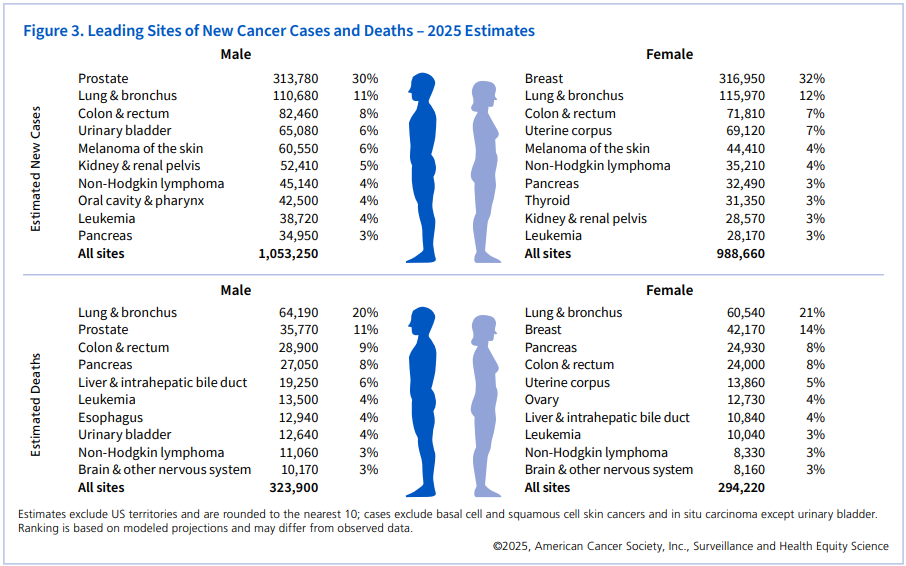

#Loading Data
Dataset consists of 220,025 images for training, and 57,458 images for testing. Files are named with an image id. The train_labels.csv file provides the actual class for the images in the train folder. We are predicting the labels for the images in the test folder. A positive label indicates that the center 32x32px region of a patch contains at least one pixel of tumor tissue. Tumor tissue in the outer region of the patch does not influence the label.

In [ ]:
import os

zip_file_path = '/content/drive/MyDrive/CNN_Project/histopathologic-cancer-detection.zip'
destination_folder = '/content/cnn_data'

# Create the destination folder if it doesn't exist
os.makedirs(destination_folder, exist_ok=True)

# Unzip the file to the destination folder
!unzip -q "{zip_file_path}" -d "{destination_folder}"

print(f"File '{zip_file_path}' unzipped to '{destination_folder}'.")

# Verify the contents of the unzipped folder (optional, display first few items)
print(f"\nContents of '{destination_folder}' (first 5 items):")
!ls "{destination_folder}" | head -n 5

File '/content/drive/MyDrive/CNN_Project/histopathologic-cancer-detection.zip' unzipped to '/content/cnn_data'.

Contents of '/content/cnn_data' (first 5 items):
sample_submission.csv
test
train
train_labels.csv


In [ ]:
import os

source_file_path = '/content/drive/MyDrive/CNN_Project/histopathologic-cancer-detection.zip'
destination_path = '/content/'

# Ensure the destination directory exists (it should for /content/)
os.makedirs(destination_path, exist_ok=True)

# Copy the file
!cp "{source_file_path}" "{destination_path}"

print(f"File copied from '{source_file_path}' to '{destination_path}'.")

# Verify the copy by listing the file in the destination
print(f"\nContents of '{destination_path}':")
!ls -lh "{destination_path}" | grep "histopathologic-cancer-detection.zip"

File copied from '/content/drive/MyDrive/CNN_Project/histopathologic-cancer-detection.zip' to '/content/'.

Contents of '/content/':
-rw------- 1 root root 6.4G Nov 23 02:13 histopathologic-cancer-detection.zip


In [1]:
import os

parent_directory_path = '/content/cnn_data'
target_directory_name = 'train'
full_target_path = os.path.join(parent_directory_path, target_directory_name)

# Get all entries in the directory
all_entries = os.listdir(full_target_path)
# Filter out directories and count only files
files = [entry for entry in all_entries if os.path.isfile(os.path.join(full_target_path, entry))]
file_count = len(files)
print(f"\nThere are {file_count} files in '{full_target_path}'.")


There are 220025 files in '/content/cnn_data/train'.


#Exploratory Data Analysis
59.5% of the training dataset reporesent images with class 1 (cancer cells  detected). Remaining 40.5% represent the images classifed as 0 (no cancer cells detected).

In [2]:
image_ids = [file.replace('.tif', '') for file in files]

In [3]:
import pandas as pd

train_df = pd.DataFrame({'id': image_ids})

print('First 5 rows of train_df:')
display(train_df.head())

First 5 rows of train_df:


,id
0,948b41645732c1578872cdf00e194b661987854b
1,94a6706e292eeb484cfa23b3ea0f135422b5fa05
2,67327861b205b63358d090274bf9992eda2417eb
3,595c9cf9baaad136f20903ba77c9acd0bb185cd1
4,f09b1ca662b36771077063239989116f227db8c2


In [4]:
labels_file_path = '/content/cnn_data/train_labels.csv'
df_labels = pd.read_csv(labels_file_path)

print('First 5 rows of df_labels:')
display(df_labels.head())

First 5 rows of df_labels:


,id,label
0,f38a6374c348f90b587e046aac6079959adf3835,0
1,c18f2d887b7ae4f6742ee445113fa1aef383ed77,1
2,755db6279dae599ebb4d39a9123cce439965282d,0
3,bc3f0c64fb968ff4a8bd33af6971ecae77c75e08,0
4,068aba587a4950175d04c680d38943fd488d6a9d,0


In [5]:
train_df = pd.merge(train_df, df_labels, on='id', how='left')

print('First 5 rows of merged train_df:')
display(train_df.head())

First 5 rows of merged train_df:


,id,label
0,948b41645732c1578872cdf00e194b661987854b,1
1,94a6706e292eeb484cfa23b3ea0f135422b5fa05,0
2,67327861b205b63358d090274bf9992eda2417eb,0
3,595c9cf9baaad136f20903ba77c9acd0bb185cd1,0
4,f09b1ca662b36771077063239989116f227db8c2,1


In [6]:
label_counts = train_df['label'].value_counts()
label_percentages = (train_df['label'].value_counts(normalize=True) * 100).round(1)

# Combine into a single DataFrame
label_distribution = pd.DataFrame({
    'Count': label_counts,
    'Percentage': label_percentages.astype(str) + '%'
})

print('Label Distribution:')
display(label_distribution)

Label Distribution:


,Count,Percentage
label,,
0,130908,59.5%
1,89117,40.5%


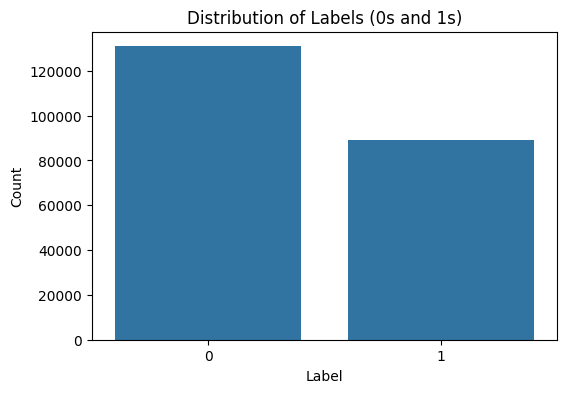

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar chart using label_counts
plt.figure(figsize=(6, 4))
sns.barplot(x=label_counts.index, y=label_counts.values)

# Set the title and axis labels
plt.title('Distribution of Labels (0s and 1s)')
plt.xlabel('Label')
plt.ylabel('Count')

# Display the plot
plt.show()


In [8]:
import pandas as pd

training_subset = 2000
samples_per_label = training_subset // 2

# Filter train_df by label
df_label_0 = train_df[train_df['label'] == 0]
df_label_1 = train_df[train_df['label'] == 1]

# Sample random rows for each label
sampled_0 = df_label_0.sample(n=samples_per_label, random_state=42)
sampled_1 = df_label_1.sample(n=samples_per_label, random_state=42)

# Combine the sampled dataframes
train_df_staging_1 = pd.concat([sampled_0, sampled_1]).sample(frac=1, random_state=42).reset_index(drop=True)

label_counts_staging = train_df_staging_1['label'].value_counts()
label_percentages_staging = (train_df_staging_1['label'].value_counts(normalize=True) * 100).round(1)

# Combine into a single DataFrame
label_distribution_staging = pd.DataFrame({
    'Count': label_counts_staging,
    'Percentage': label_percentages_staging.astype(str) + '%'
})

print('Label Distribution for train_df_staging_1:')
display(label_distribution_staging)

Label Distribution for train_df_staging_1:


,Count,Percentage
label,,
1,1000,50.0%
0,1000,50.0%


##Training Dataset
After several iterations and adjustments, the dataset size used for model training was reduced to 2,000 observations. On an average laptop (CPU only), training a model with 10,000 observations can take several hours, making the smaller dataset more practical for experimentation.
Because the original dataset was slightly imbalanced (60% positive cases vs. 40% negative cases), the training data was resampled to achieve a balanced 50/50 distribution between classes. Of the 2,000 total observations:
- **1,600 observations** (800 positive and 800 negative) were allocated for model training.
- **400 observations** (200 positive and 200 negative) were reserved for validation, ensuring effective monitoring of overfitting.

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Split train_df_staging_1 by label to ensure stratification
df_label_0 = train_df_staging_1[train_df_staging_1['label'] == 0]
df_label_1 = train_df_staging_1[train_df_staging_1['label'] == 1]

# 80% for training data (400 samples each)
train_0, val_0 = train_test_split(df_label_0, test_size=0.2, random_state=42, stratify=df_label_0['label'])
train_1, val_1 = train_test_split(df_label_1, test_size=0.2, random_state=42, stratify=df_label_1['label'])

# Combine and shuffle for train_data and validation_data
train_data = pd.concat([train_0, train_1]).sample(frac=1, random_state=42).reset_index(drop=True)
validation_data = pd.concat([val_0, val_1]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Shape of train_data:", train_data.shape)
print("Shape of validation_data:", validation_data.shape)

print('\nLabel Distribution for train_data:')
label_counts_train = train_data['label'].value_counts()
label_percentages_train = (train_data['label'].value_counts(normalize=True) * 100).round(1)
label_distribution_train = pd.DataFrame({
    'Count': label_counts_train,
    'Percentage': label_percentages_train.astype(str) + '%'
})
display(label_distribution_train)

print('\nLabel Distribution for validation_data:')
label_counts_val = validation_data['label'].value_counts()
label_percentages_val = (validation_data['label'].value_counts(normalize=True) * 100).round(1)
label_distribution_val = pd.DataFrame({
    'Count': label_counts_val,
    'Percentage': label_percentages_val.astype(str) + '%'
})
display(label_distribution_val)

Shape of train_data: (1600, 2)
Shape of validation_data: (400, 2)

Label Distribution for train_data:


,Count,Percentage
label,,
0,800,50.0%
1,800,50.0%



Label Distribution for validation_data:


,Count,Percentage
label,,
1,200,50.0%
0,200,50.0%


In [10]:
df_label_0_sample = train_df_staging_1[train_df_staging_1['label'] == 0]
df_label_1_sample = train_df_staging_1[train_df_staging_1['label'] == 1]

sample_ids_0 = df_label_0_sample['id'].sample(n=5, random_state=42).tolist()
sample_ids_1 = df_label_1_sample['id'].sample(n=5, random_state=42).tolist()

sampled_image_ids = sample_ids_0 + sample_ids_1

print("Sampled IDs for label 0:", sample_ids_0)
print("Sampled IDs for label 1:", sample_ids_1)
print("Concatenated sampled image IDs:", sampled_image_ids)

Sampled IDs for label 0: ['1bfa6170a6f8bb3ffe5bfb1ecb48a8f69ec1108f', '0d30efcbb0486f81faaf60b400f6ebc935610b53', '9a1752ff08e0344ae506cbea691651627eda0931', 'bb2bd8f839b87ecbafe36722e714faaaa0194bc7', 'fb0f544a36a409c6a43217fd2331399087ef37d5']
Sampled IDs for label 1: ['c1e8d76b8dbbb5b0807da7212cd954d197deeff2', '3e565af77826d4c0312c73a7153fe166deab69b9', '4661be941d444e3623bac22dd3b0293845bb687b', '65abbee2ea04eb21486ba017e27cd3210d8bcf1a', '34158be4424d7b8b4b23f81cae612ec83d92cfa0']
Concatenated sampled image IDs: ['1bfa6170a6f8bb3ffe5bfb1ecb48a8f69ec1108f', '0d30efcbb0486f81faaf60b400f6ebc935610b53', '9a1752ff08e0344ae506cbea691651627eda0931', 'bb2bd8f839b87ecbafe36722e714faaaa0194bc7', 'fb0f544a36a409c6a43217fd2331399087ef37d5', 'c1e8d76b8dbbb5b0807da7212cd954d197deeff2', '3e565af77826d4c0312c73a7153fe166deab69b9', '4661be941d444e3623bac22dd3b0293845bb687b', '65abbee2ea04eb21486ba017e27cd3210d8bcf1a', '34158be4424d7b8b4b23f81cae612ec83d92cfa0']


After image IDs for sampling are prepared, the next step is to retrieve their corresponding labels and prepare the image paths for visualization.



In [11]:
import os

# Create a DataFrame from the sampled IDs to easily merge with labels
sampled_df = pd.DataFrame({'id': sampled_image_ids})

# Get the labels for the sampled images by merging with train_df_staging_1
sampled_df_with_labels = pd.merge(sampled_df, train_df_staging_1[['id', 'label']], on='id', how='left')

# Define the directory where the images are stored
image_dir = '/content/cnn_data/train'

# Add the full path to the images in the DataFrame
sampled_df_with_labels['image_path'] = sampled_df_with_labels['id'].apply(lambda x: os.path.join(image_dir, x + '.tif'))

print("Sampled DataFrame with labels and image paths:")
display(sampled_df_with_labels.head())

Sampled DataFrame with labels and image paths:


,id,label,image_path
0,1bfa6170a6f8bb3ffe5bfb1ecb48a8f69ec1108f,0,/content/cnn_data/train/1bfa6170a6f8bb3ffe5bfb...
1,0d30efcbb0486f81faaf60b400f6ebc935610b53,0,/content/cnn_data/train/0d30efcbb0486f81faaf60...
2,9a1752ff08e0344ae506cbea691651627eda0931,0,/content/cnn_data/train/9a1752ff08e0344ae506cb...
3,bb2bd8f839b87ecbafe36722e714faaaa0194bc7,0,/content/cnn_data/train/bb2bd8f839b87ecbafe367...
4,fb0f544a36a409c6a43217fd2331399087ef37d5,0,/content/cnn_data/train/fb0f544a36a409c6a43217...


##Visual Inspection
We began by displaying **five "positive" and five "negative" scans side by side**. Several initial observations were made:
- The images are 96 × 96 pixels in size.
- Negative scans tend to appear slightly brighter than positive scans.
- Most images contain small, oval-shaped elements that may provide information relevant to classification.
- There appears to be no discernible "up" and "down" directions, suggesting that the scans may have been captured at random rotations.

Additionally, one example of each class ("positive" and "negative") was examined in greater detail. **Zoomed-in views of the central 32 × 32 pixel** regions revealed distinct differences:
- The negative sample displayed a dense, ordered structure of oval-shaped elements, primarily in a purple and pink color palette.
- The negative sample also contained a large, bright area, contrasting with the more uniform appearance of the positive sample.

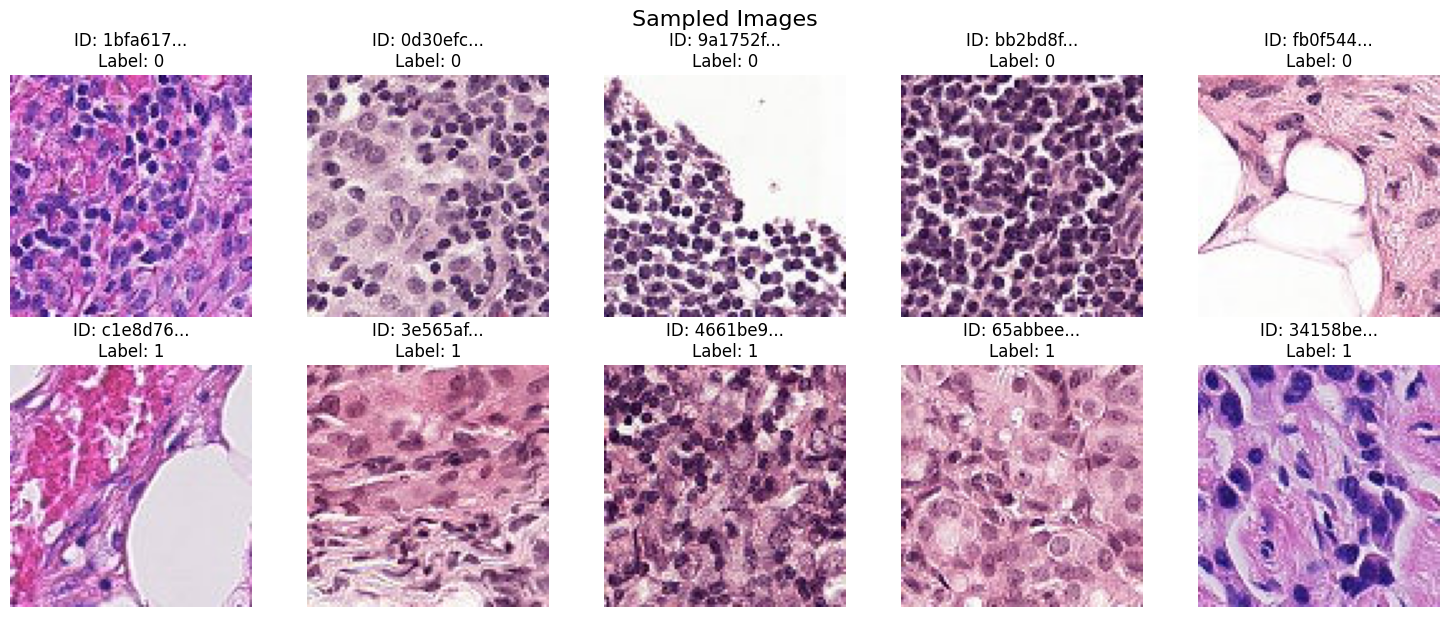


Summary of displayed images:
                                      id  label
1bfa6170a6f8bb3ffe5bfb1ecb48a8f69ec1108f      0
0d30efcbb0486f81faaf60b400f6ebc935610b53      0
9a1752ff08e0344ae506cbea691651627eda0931      0
bb2bd8f839b87ecbafe36722e714faaaa0194bc7      0
fb0f544a36a409c6a43217fd2331399087ef37d5      0
c1e8d76b8dbbb5b0807da7212cd954d197deeff2      1
3e565af77826d4c0312c73a7153fe166deab69b9      1
4661be941d444e3623bac22dd3b0293845bb687b      1
65abbee2ea04eb21486ba017e27cd3210d8bcf1a      1
34158be4424d7b8b4b23f81cae612ec83d92cfa0      1


In [12]:
import matplotlib.pyplot as plt
from PIL import Image

# Set up the matplotlib figure and axes
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 6))
axes = axes.flatten() # Flatten the 2x5 array of axes for easier iteration

# Loop through the sampled images and display them
for i, row in sampled_df_with_labels.iterrows():
    image_path = row['image_path']
    image_id = row['id']
    label = row['label']

    # Open the image
    try:
        img = Image.open(image_path)
        axes[i].imshow(img)
        axes[i].set_title(f"ID: {image_id[:7]}...\nLabel: {label}") # Shorten ID for title
        axes[i].axis('off') # Hide axes
    except FileNotFoundError:
        print(f"Warning: Image not found at {image_path}")
        axes[i].set_title(f"Image not found\nID: {image_id[:7]}...")
        axes[i].axis('off')

plt.tight_layout()
plt.suptitle('Sampled Images', y=1.02, fontsize=16)
plt.show()

print("\nSummary of displayed images:")
print(sampled_df_with_labels[['id', 'label']].to_string(index=False))


--- Exploring Image ID: 1bfa6170a6f8bb3ffe5bfb1ecb48a8f69ec1108f (Label: 0) ---
Image Path: /content/cnn_data/train/1bfa6170a6f8bb3ffe5bfb1ecb48a8f69ec1108f.tif
Resolution: 96x96 pixels
Color Mode: RGB, Depth (channels): 3


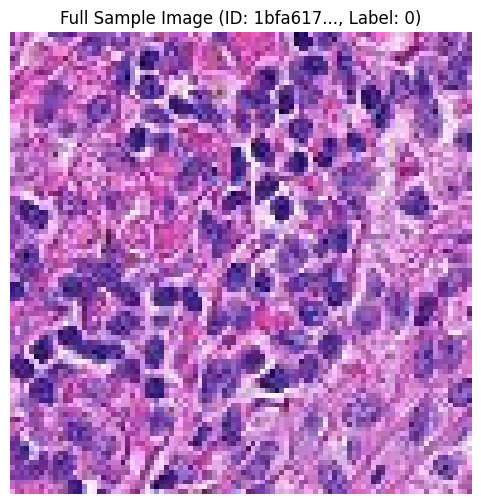

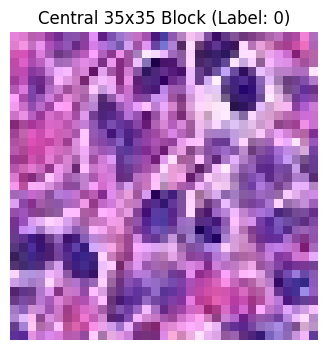

First 5x5 pixel values of the central 35x35 block (top-left corner of the block):
[[233 221 183 188 147]
 [223 242 195 235 172]
 [209 214 172 221 165]
 [192 222 172 187 225]
 [187 193 137 148 203]]

--- Exploring Image ID: c1e8d76b8dbbb5b0807da7212cd954d197deeff2 (Label: 1) ---
Image Path: /content/cnn_data/train/c1e8d76b8dbbb5b0807da7212cd954d197deeff2.tif
Resolution: 96x96 pixels
Color Mode: RGB, Depth (channels): 3


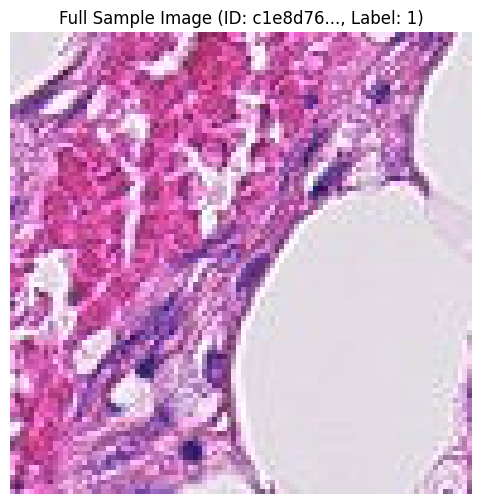

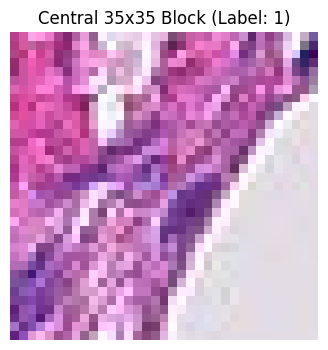

First 5x5 pixel values of the central 35x35 block (top-left corner of the block):
[[185 215 253 255 235]
 [176 211 188 183 202]
 [176 179 255 204 216]
 [148 205 240 217 202]
 [145 202 229 214 233]]


In [13]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Select one image with label 0 and one with label 1 from sampled_df_with_labels
image_0_row = sampled_df_with_labels[sampled_df_with_labels['label'] == 0].iloc[0]
image_1_row = sampled_df_with_labels[sampled_df_with_labels['label'] == 1].iloc[0]

selected_images_rows = [image_0_row, image_1_row]

for image_row in selected_images_rows:
    image_path = image_row['image_path']
    image_id = image_row['id']
    image_label = image_row['label']

    print(f"\n--- Exploring Image ID: {image_id} (Label: {image_label}) ---")
    print(f"Image Path: {image_path}")

    try:
        img = Image.open(image_path)

        # Get resolution (width, height)
        width, height = img.size
        print(f"Resolution: {width}x{height} pixels")

        # Get depth (number of channels based on mode)
        mode = img.mode
        depth = len(mode) if 'L' not in mode else 1 # 'L' is for 1-channel grayscale
        print(f"Color Mode: {mode}, Depth (channels): {depth}")

        # Display the full image
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.title(f"Full Sample Image (ID: {image_id[:7]}..., Label: {image_label})")
        plt.axis('off')
        plt.show()

        # Convert to numpy array to access pixel values easily
        img_array = np.array(img)

        # Extract 35x35 pixel block from the center
        block_size = 35
        start_x = (width - block_size) // 2
        start_y = (height - block_size) // 2
        end_x = start_x + block_size
        end_y = start_y + block_size

        center_block = img_array[start_y:end_y, start_x:end_x]

        # Display the central 35x35 pixel block
        plt.figure(figsize=(4, 4))
        plt.imshow(center_block)
        plt.title(f"Central {block_size}x{block_size} Block (Label: {image_label})")
        plt.axis('off')
        plt.show()

        # What the data looks like (e.g., a small part of the pixel array)
        print(f"First 5x5 pixel values of the central {block_size}x{block_size} block (top-left corner of the block):")
        # For RGB images, show first channel or average
        if len(center_block.shape) == 3:
            print(center_block[:5, :5, 0]) # Show red channel values
        else:
            print(center_block[:5, :5]) # Grayscale values

    except FileNotFoundError:
        print(f"Error: Image not found at {image_path}")
    except Exception as e:
        print(f"An error occurred: {e}")

##Color Histograms and Brightness
To further investigate potential distinctions between classes, individual color channels (red, green, and blue) were analyzed. In addition, overall brightness was examined by averaging the values across all three channels. Key observations include:
- All color channels exhibit a **bimodal distribution for the negative class**, whereas the positive class shows a unimodal distribution.
- One of the peaks in the average color value for the negative class is close to the single peak observed in the positive class.
- The other peak in the negative class lies on the darker end of the spectrum, corresponding to higher color intensity values.

Based on these findings, it can be hypothesized that **approximately half of the negative cases are characterized by a distinctly darker color palette**. This **darker spectrum may serve as a reliable predictor for identifying negative cases**. However, the remaining half of the negative cases closely resemble the positive cases in terms of color intensity, making them less distinguishable based solely on brightness or color distribution.

In [14]:
image_stats_list = []
image_dir = '/content/cnn_data/train'

for index, row in train_df_staging_1.iterrows():
    image_id = row['id']
    label = row['label']
    image_path = os.path.join(image_dir, image_id + '.tif')

    try:
        img = Image.open(image_path)
        img_array = np.array(img)

        # Calculate average R, G, B channel values
        # Assuming RGB image with shape (height, width, 3)
        avg_r = img_array[:, :, 0].mean()
        avg_g = img_array[:, :, 1].mean()
        avg_b = img_array[:, :, 2].mean()

        # Calculate overall average brightness (mean of all pixel values)
        avg_brightness = img_array.mean()

        image_stats_list.append({
            'id': image_id,
            'label': label,
            'avg_r': avg_r,
            'avg_g': avg_g,
            'avg_b': avg_b,
            'avg_brightness': avg_brightness
        })
    except FileNotFoundError:
        print(f"Warning: Image not found at {image_path}. Skipping.")
    except Exception as e:
        print(f"Error processing image {image_id}: {e}. Skipping.")

image_stats_df = pd.DataFrame(image_stats_list)

print("First 5 rows of image_stats_df:")
display(image_stats_df.head())
print("Shape of image_stats_df:", image_stats_df.shape)

First 5 rows of image_stats_df:


,id,label,avg_r,avg_g,avg_b,avg_brightness
0,862ceb4ded508812c330556dacf2fc76a3556d5c,1,192.531359,132.978841,202.742079,176.084093
1,e5aeda6608c355abc7c60f7ffe8bd724043e782b,0,237.592882,231.875434,232.869792,234.112703
2,d7524644d4377390be1b2786ee3f3e9669fb2be0,1,142.399197,68.876302,160.651476,123.975658
3,626f2c0dc0ccc0ed9971e8fbe2c1c545a815bc23,0,166.330838,117.498915,146.269748,143.366500
4,93b00b5796ba4cb4772953275bafe6a626a4e7c4,1,142.548937,70.790365,162.918294,125.419198


Shape of image_stats_df: (2000, 6)


In [15]:
label_0_stats = image_stats_df[image_stats_df['label'] == 0][['avg_r', 'avg_g', 'avg_b', 'avg_brightness']].agg(['mean', 'median', 'std']).T
label_1_stats = image_stats_df[image_stats_df['label'] == 1][['avg_r', 'avg_g', 'avg_b', 'avg_brightness']].agg(['mean', 'median', 'std']).T

print('Summary Statistics for Label 0:')
display(label_0_stats)

print('\nSummary Statistics for Label 1:')
display(label_1_stats)

Summary Statistics for Label 0:


,mean,median,std
avg_r,180.058566,178.100586,40.989467
avg_g,145.879500,136.364366,53.612091
avg_b,178.686988,175.855035,37.863469
avg_brightness,168.208351,161.607440,43.179426



Summary Statistics for Label 1:


,mean,median,std
avg_r,176.746149,177.100532,28.064652
avg_g,129.406409,125.772949,37.438805
avg_b,175.475802,177.233344,24.478821
avg_brightness,160.542786,158.143428,28.175310


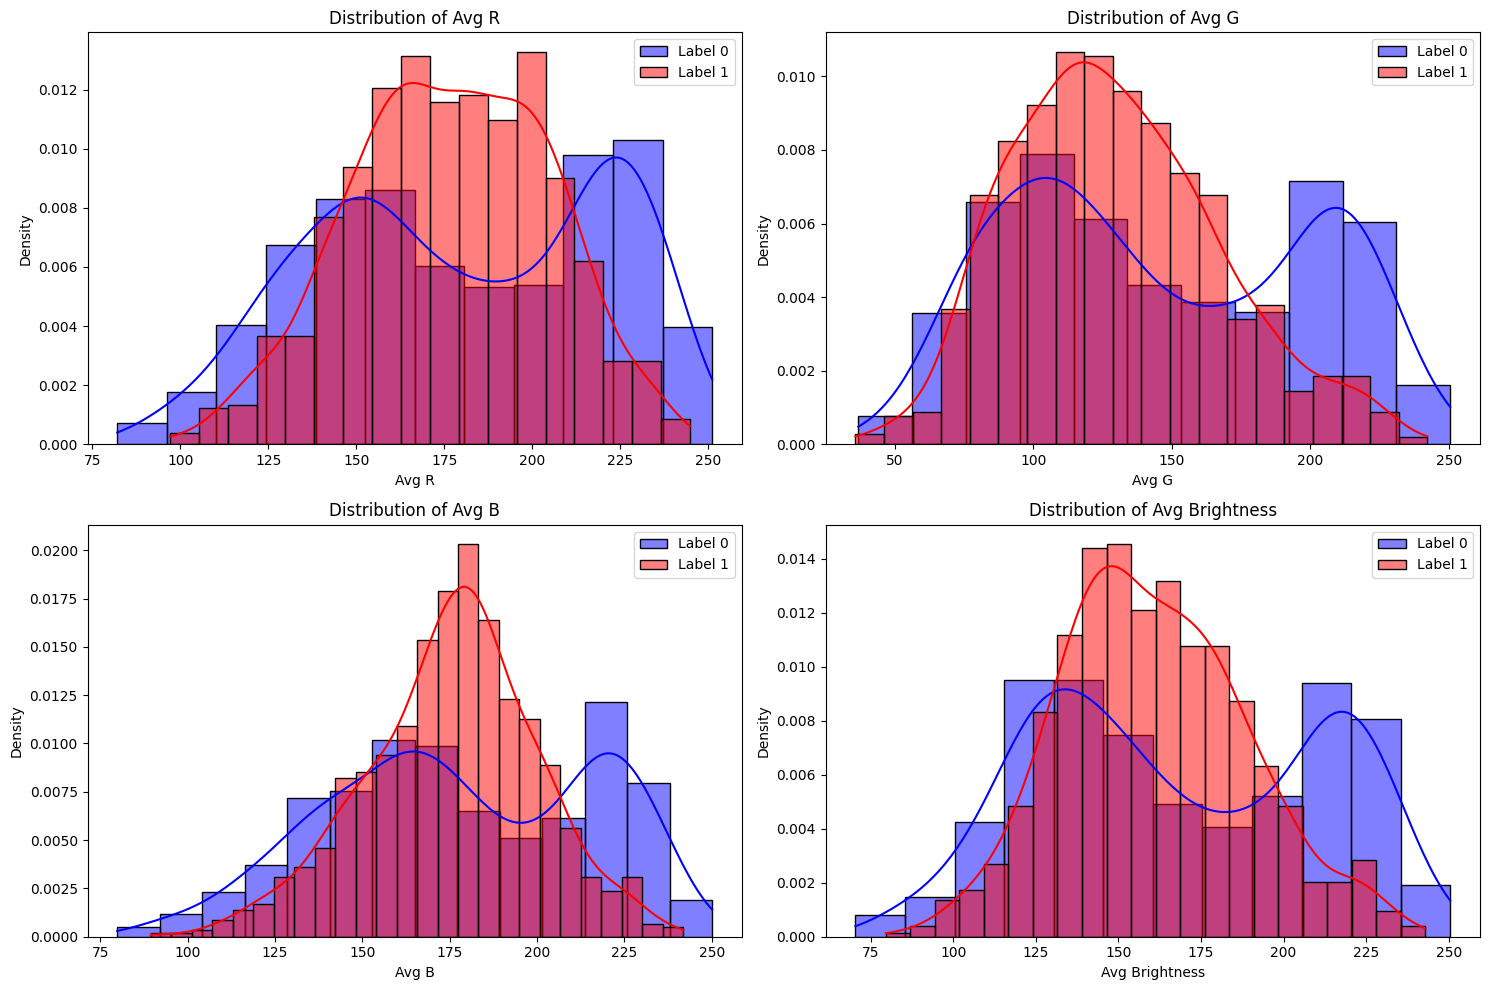

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Features to visualize
features = ['avg_r', 'avg_g', 'avg_b', 'avg_brightness']

plt.figure(figsize=(15, 10))

for i, feature in enumerate(features):
    plt.subplot(2, 2, i + 1)
    sns.histplot(data=image_stats_df[image_stats_df['label'] == 0], x=feature, color='blue', label='Label 0', kde=True, stat='density', alpha=0.5)
    sns.histplot(data=image_stats_df[image_stats_df['label'] == 1], x=feature, color='red', label='Label 1', kde=True, stat='density', alpha=0.5)
    plt.title(f'Distribution of {feature.replace("_", " ").title()}')
    plt.xlabel(feature.replace("_", " ").title())
    plt.ylabel('Density')
    plt.legend()

plt.tight_layout()
plt.show()


##Data Preparation
Based on the visual inspection and color distribution analysis, the following data preparation steps were applied:
- Normalization: Pixel values were scaled to the range [0, 1].
- Rotation: Images were randomly rotated by up to 20 degrees.
- Zoom: Random zoom transformations of up to 15% were applied.
- Shear: Shear transformations were introduced to increase variability.
- Horizontal flipping: Images were randomly flipped horizontally to enhance robustness against orientation bias.

In [17]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 2. Define the desired image dimensions and batch size
IMG_WIDTH = 96
IMG_HEIGHT = 96
BATCH_SIZE = 32

# Define the image directory
image_dir = '/content/cnn_data/train'

# Modify 'id' columns in dataframes to include file extension
train_data_modified = train_data.copy()
validation_data_modified = validation_data.copy()
train_data_modified['id'] = train_data_modified['id'].astype(str) + '.tif'
validation_data_modified['id'] = validation_data_modified['id'].astype(str) + '.tif'

# 3. Create an ImageDataGenerator for the training data with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,                 # Normalize pixel values to [0, 1]
    rotation_range=20,              # Randomly rotate images by up to 20 degrees
    zoom_range=0.15,                # Randomly zoom images by up to 15%
    shear_range=0.15,               # Apply shear transformation
    horizontal_flip=True,           # Randomly flip images horizontally
    fill_mode='nearest'             # Strategy for filling in new pixels created by rotation or shifts
)

# 4. Create a separate ImageDataGenerator for the validation data (only normalization)
validation_datagen = ImageDataGenerator(rescale=1./255)

# 5. Use flow_from_dataframe to create a training data generator
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_data_modified,
    directory=image_dir,
    x_col='id',
    y_col='label',
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=True,
    seed=42
)

# 6. Use flow_from_dataframe to create a validation data generator
validation_generator = validation_datagen.flow_from_dataframe(
    dataframe=validation_data_modified,
    directory=image_dir,
    x_col='id',
    y_col='label',
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=False, # Do not shuffle validation data
    seed=42
)

# 7. Print the shapes of a batch of images and their corresponding labels
print("\nVerifying output from training generator:")
images_batch, labels_batch = next(train_generator)
print(f"Shape of images batch: {images_batch.shape}") # Expected: (BATCH_SIZE, IMG_WIDTH, IMG_HEIGHT, 3)
print(f"Shape of labels batch: {labels_batch.shape}") # Expected: (BATCH_SIZE,)

print("Data generators created successfully.")

Found 1600 validated image filenames.
Found 400 validated image filenames.

Verifying output from training generator:
Shape of images batch: (32, 96, 96, 3)
Shape of labels batch: (32,)
Data generators created successfully.


#Initial CNN Model


##Model Architecture
The initial convolutional neural network (CNN) model was designed with the following architecture:
- **Three convolutional layers with 64, 32, and 16 filters** applied sequentially. Each convolutional layer is followed by a Max Pooling operation to reduce spatial dimensions while retaining key features.
- Each convolutional layer employs the **ReLU activation function**, which helps preserve information from the original image while introducing non-linear transformations.
- The **classifier stage consists of one hidden fully connected layer**, followed by the final output layer.
- The final **output layer uses a sigmoid activation function**, enabling binary classification between positive and negative cases.

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras import Input

# 1. Initialize a Sequential model
model = Sequential()

# Add Input layer explicitly
model.add(Input(shape=(IMG_WIDTH, IMG_HEIGHT, 3)))

# 2. Add Convolutional and Pooling layers
# First Conv2D and MaxPooling2D block
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# Second Conv2D and MaxPooling2D block
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# Third Conv2D and MaxPooling2D block
model.add(Conv2D(16, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# 3. Flatten the output to feed into dense layers
model.add(Flatten())

# 4. Add Dense (fully connected) layers
model.add(Dense(16, activation='relu'))

# 5. Add the final output layer for binary classification
model.add(Dense(1, activation='sigmoid'))

# Print the model summary to verify the architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 94, 94, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        25,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,513 (197.32 KB)

 Trainable params: 50,513 (197.32 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
import tensorflow as tf

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

print("Model compiled successfully.")

Model compiled successfully.


##Model Training
To manage overfitting and reduce training time, an **early stopping condition** was implemented. After several trials, it was determined that training should stop **if no improvement** in the validation loss was observed **for 10 consecutive epochs**. In addition, the maximum number of epochs was capped at 50 to further control training duration.

In [20]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 1. Define EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',     # Monitor the validation loss
    patience=10,             # Stop if val_loss doesn't improve for 10 epochs
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity.
)

# 2. Define ModelCheckpoint callback
model_checkpoint = ModelCheckpoint(
    filepath='best_model2.keras', # Path to save the best model weights
    monitor='val_accuracy',      # Monitor validation accuracy
    save_best_only=True,         # Save only the best model
    mode='max',                  # Save when val_accuracy is maximized
    verbose=1
)

# 3. Train the model
EPOCHS = 50 # Set a reasonable number of epochs

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=[early_stopping, model_checkpoint] # Pass the list of callbacks
)

print("Model training complete. Training history stored in 'history' variable.")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 751ms/step - accuracy: 0.4954 - loss: 0.6933 - precision: 0.4872 - recall: 0.2232
Epoch 1: val_accuracy improved from -inf to 0.51500, saving model to best_model2.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 45s 805ms/step - accuracy: 0.4959 - loss: 0.6932 - precision: 0.4881 - recall: 0.2245 - val_accuracy: 0.5150 - val_loss: 0.6580 - val_precision: 0.5385 - val_recall: 0.2100
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 748ms/step - accuracy: 0.5896 - loss: 0.6707 - precision: 0.5903 - recall: 0.5963
Epoch 2: val_accuracy improved from 0.51500 to 0.60500, saving model to best_model2.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 40s 791ms/step - accuracy: 0.5897 - loss: 0.6706 - precision: 0.5902 - recall: 0.5975 - val_accuracy: 0.6050 - val_loss: 0.6580 - val_precision: 0.6117 - val_recall: 0.5750
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 710ms/step - accuracy: 0.5580 - loss: 0.6720 - precision: 0.5422 - recall: 0.7980
Epoch 3: val_accuracy improved from 0.60500 to 0.64000

##Model Results
The initial model achieved an accuracy of approximately 78% on the validation set. As illustrated by the training chart, a substantial improvement in accuracy occurred around epoch 20, where performance increased from just above 60% to nearly 80%. This indicates that the early stopping condition should be sufficiently flexible to allow training to continue beyond periods of stagnation in accuracy values.

Overall, the chart appears quite noisy, which likely reflects the relatively small sample size used in training. Another possible explanation is that the model architecture may not be sufficiently deep or complex to capture the full variability present in the data.


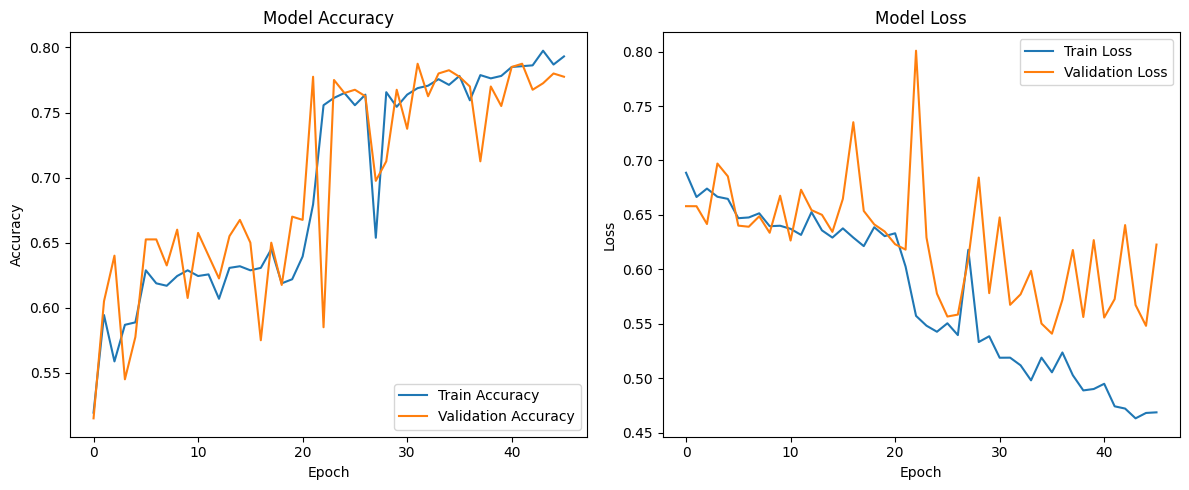

Training history plots displayed.


In [21]:
import matplotlib.pyplot as plt

# Get the training history
hist = history.history

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(hist['accuracy'], label='Train Accuracy')
plt.plot(hist['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(hist['loss'], label='Train Loss')
plt.plot(hist['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

print("Training history plots displayed.")

In [22]:
evaluation_results = model.evaluate(validation_generator)

print("\nModel Evaluation Results on Validation Data:")
print(f"Validation Loss: {evaluation_results[0]:.4f}")
print(f"Validation Accuracy: {evaluation_results[1]:.4f}")
print(f"Validation Precision: {evaluation_results[2]:.4f}")
print(f"Validation Recall: {evaluation_results[3]:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 164ms/step - accuracy: 0.7838 - loss: 0.5329 - precision: 0.7540 - recall: 0.8156

Model Evaluation Results on Validation Data:
Validation Loss: 0.5408
Validation Accuracy: 0.7775
Validation Precision: 0.7581
Validation Recall: 0.8150


#Updated CNN Model

##Model Architecture
To balance model complexity with the computational limits of a lower-end machine, the initial CNN architecture was upgraded as follows:
- The number of filters in each convolutional layer was doubled, increasing the model’s capacity to capture more detailed features.
- The pooling operation was modified, replacing Max Pooling with Average Pooling to provide a smoother representation of feature maps.
- Dropout regularization was tested but ultimately discarded, as the model performed poorly with it, struggling to exceed the baseline accuracy of approximately 50%.
- As a result of these changes, the total number of optimization parameters doubled, increasing from approximately 50,000 to 100,000.

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense, Dropout
from tensorflow.keras import Input

# 1. Initialize a Sequential model
model_updated = Sequential()

# Add Input layer explicitly
model_updated.add(Input(shape=(IMG_WIDTH, IMG_HEIGHT, 3)))

# 2. Add Convolutional and Pooling layers
# First Conv2D and MaxPooling2D block
model_updated.add(Conv2D(128, (3, 3), activation='relu'))
model_updated.add(AveragePooling2D((2, 2)))

model_updated.add(Conv2D(64, (3, 3), activation='relu'))
model_updated.add(AveragePooling2D((2, 2)))

# Second Conv2D and MaxPooling2D block
model_updated.add(Conv2D(32, (3, 3), activation='relu'))
model_updated.add(AveragePooling2D((2, 2)))

# Third Conv2D and MaxPooling2D block
model_updated.add(Conv2D(16, (3, 3), activation='relu'))
model_updated.add(AveragePooling2D((2, 2)))

# 3. Flatten the output to feed into dense layers
model_updated.add(Flatten())

# 4. Add Dense (fully connected) layers
model_updated.add(Dense(16, activation='relu'))

# 5. Add the final output layer for binary classification
model_updated.add(Dense(1, activation='sigmoid'))

# Print the model summary to verify the architecture
model_updated.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 94, 94, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 47, 47, 128)    │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 45, 45, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 22, 22, 64)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 20, 20, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 10, 10, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 16)       │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         4,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,593 (408.57 KB)

 Trainable params: 104,593 (408.57 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
import tensorflow as tf

# Compile the updated model
model_updated.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

print("Updated model compiled successfully.")

Updated model compiled successfully.


In [25]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define EarlyStopping callback (can reuse the one defined for the previous model)
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Define ModelCheckpoint callback for the updated model
model_checkpoint_updated = ModelCheckpoint(
    filepath='best_model_updated3.keras', # Save the best updated model
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Train the updated model
EPOCHS = 50 # Use the same number of epochs, EarlyStopping will manage when to stop

history_updated = model_updated.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=[early_stopping, model_checkpoint_updated]
)

print("Updated model training complete. Training history stored in 'history_updated' variable.")

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4979 - loss: 0.6941 - precision_1: 0.4362 - recall_1: 0.2366
Epoch 1: val_accuracy improved from -inf to 0.49250, saving model to best_model_updated3.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.4981 - loss: 0.6941 - precision_1: 0.4378 - recall_1: 0.2365 - val_accuracy: 0.4925 - val_loss: 0.6893 - val_precision_1: 0.4348 - val_recall_1: 0.0500
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5511 - loss: 0.6781 - precision_1: 0.6241 - recall_1: 0.2775
Epoch 2: val_accuracy improved from 0.49250 to 0.64500, saving model to best_model_updated3.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.5517 - loss: 0.6778 - precision_1: 0.6235 - recall_1: 0.2821 - val_accuracy: 0.6450 - val_loss: 0.6317 - val_precision_1: 0.6058 - val_recall_1: 0.8300
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6937 - loss: 0.5836 - precision_1: 0.6847 - recall_1: 0.6990
Epoch 3: val_accuracy did

##Model Results
The updated model trained in a **somewhat more stable** manner compared to the initial version, with no abrupt jumps in accuracy observed during training. However, the overall **performance was not significantly improved**, as the updated model’s accuracy failed to meaningfully surpass that of the baseline.
After doubling the number of filters, the updated model achieved a validation accuracy of 78.5%, which is only marginally higher than the baseline model’s 77.8%. This suggests that the architectural adjustments provided limited benefit, and further improvements may require either a larger dataset or a more complex model design.

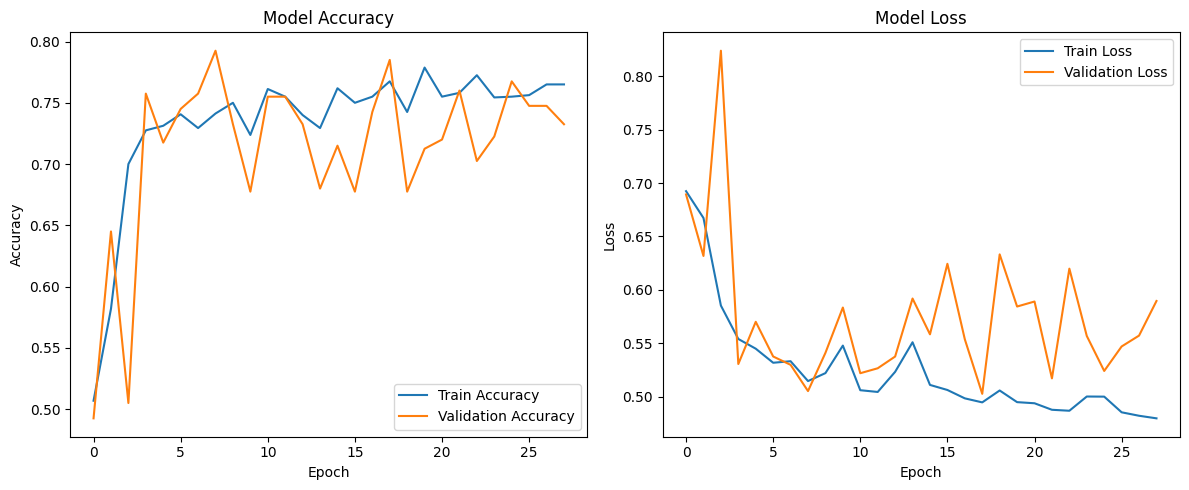

Training history plots displayed.


In [26]:
import matplotlib.pyplot as plt

# Get the training history
hist_updated = history_updated.history

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(hist_updated['accuracy'], label='Train Accuracy')
plt.plot(hist_updated['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(hist_updated['loss'], label='Train Loss')
plt.plot(hist_updated['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

print("Training history plots displayed.")

In [27]:
evaluation_results_updated = model_updated.evaluate(validation_generator)

print("\nModel Evaluation Results on Validation Data:")
print(f"Validation Loss: {evaluation_results_updated[0]:.4f}")
print(f"Validation Accuracy: {evaluation_results_updated[1]:.4f}")
print(f"Validation Precision: {evaluation_results_updated[2]:.4f}")
print(f"Validation Recall: {evaluation_results_updated[3]:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 486ms/step - accuracy: 0.7846 - loss: 0.4943 - precision_1: 0.7991 - recall_1: 0.7354

Model Evaluation Results on Validation Data:
Validation Loss: 0.5025
Validation Accuracy: 0.7850
Validation Precision: 0.8167
Validation Recall: 0.7350


#Conclusion
In this project, only a small fraction of the available training data was utilized, and the chosen model architectures were intentionally limited. Any significant expansion of the model resulted in impractically long training times given the available hardware (CPU-only, average laptop).

Between the two trained models, the initial model appears to be the better option. It is less complex yet achieves nearly the same level of accuracy as the updated model. With the relatively small sample size used for training, it is plausible that the smaller model generalizes more effectively, whereas the larger model may have overfitted the training and validation datasets.

With access to greater computational resources and the ability to train on larger datasets, several improvements could be pursued:
- A deeper CNN architecture with additional convolutional layers and larger filter banks could capture more complex spatial features.
- Techniques such as batch normalization, dropout with optimized rates, and advanced regularization methods could improve generalization.
- Leveraging transfer learning from pre-trained models on large-scale histopathology datasets would accelerate convergence and enhance accuracy.
- Finally, training with millions of samples would reduce noise and variability, enabling the model to achieve higher robustness and reliability in real-world applications.

#Preparing a Kaggle Submission File

In [28]:
import os
import pandas as pd

# Define the path to the test image directory
test_directory_path = '/content/cnn_data/test' #/content/drive/MyDrive/CNN_Project/data/test

# Get all entries in the directory
all_test_entries = os.listdir(test_directory_path)

# Filter out directories and count only files, removing the .tif extension
test_image_ids = [entry.replace('.tif', '') for entry in all_test_entries if os.path.isfile(os.path.join(test_directory_path, entry))]

# Create a Pandas DataFrame named test_df
test_df = pd.DataFrame({'id': test_image_ids})

print('First 5 rows of test_df:')
display(test_df.head())
print(f"Shape of test_df: {test_df.shape}")

First 5 rows of test_df:


,id
0,363eaf96a9edd94a0e35eb06cad5c78ba463d45c
1,c2aa10467dab872ded11d6279ecaa0e5a603d65b
2,6c803b53fa132ad754df64eb0fddefc566e1ed6d
3,f6f57c7bad6a681294ee9b54886746e96739ba5b
4,467ac2141d4300ddcae9422aa562b37a4cf24494


Shape of test_df: (57458, 1)


In [29]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Create an ImageDataGenerator for the test data (only normalization)
test_datagen = ImageDataGenerator(rescale=1./255)

# 2. Modify 'id' column in test_df to include file extension
test_df_modified = test_df.copy() # Create a copy to avoid modifying the original test_df prematurely if it's used elsewhere
test_df_modified['id'] = test_df_modified['id'].astype(str) + '.tif'

# 3. Use flow_from_dataframe to create a test data generator
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df_modified,
    directory=test_directory_path, # Use the previously defined test_directory_path
    x_col='id',
    y_col=None,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode=None,
    shuffle=False,
    seed=42
)

print("Test data generator created successfully.")

Found 57458 validated image filenames.
Test data generator created successfully.


In [30]:
import numpy as np

# Make predictions using the original model on the test generator
raw_predictions = model.predict(test_generator)

# Convert raw probabilities to binary labels (0 or 1) using a 0.5 threshold
binary_predictions = (raw_predictions >= 0.5).astype(int)

print("Raw predictions shape:", raw_predictions.shape)
print("Binary predictions shape:", binary_predictions.shape)
print("First 10 raw predictions:\n", raw_predictions[:10].flatten())
print("First 10 binary predictions:\n", binary_predictions[:10].flatten())

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1796/1796 ━━━━━━━━━━━━━━━━━━━━ 372s 207ms/step
Raw predictions shape: (57458, 1)
Binary predictions shape: (57458, 1)
First 10 raw predictions:
 [0.680811   0.30242318 0.680811   0.6800253  0.680811   0.680811
 0.5633416  0.680811   0.680811   0.1416954 ]
First 10 binary predictions:
 [1 0 1 1 1 1 1 1 1 0]


In [31]:
import pandas as pd

# 1. Create a new Pandas DataFrame named submission_df
submission_df = pd.DataFrame()

# 2. Assign the 'id' column from the existing test_df
submission_df['id'] = test_df['id']

# 3. Assign the binary_predictions to the 'label' column of submission_df
# Flatten binary_predictions as it's a 2D array (n, 1)
submission_df['label'] = binary_predictions.flatten()

# 4. Display the first 5 rows and the shape of the submission_df
print('First 5 rows of submission_df:')
display(submission_df.head())
print(f"Shape of submission_df: {submission_df.shape}")

First 5 rows of submission_df:


,id,label
0,363eaf96a9edd94a0e35eb06cad5c78ba463d45c,1
1,c2aa10467dab872ded11d6279ecaa0e5a603d65b,0
2,6c803b53fa132ad754df64eb0fddefc566e1ed6d,1
3,f6f57c7bad6a681294ee9b54886746e96739ba5b,1
4,467ac2141d4300ddcae9422aa562b37a4cf24494,1


Shape of submission_df: (57458, 2)


In [32]:
import pandas as pd

# Save the submission_df to a CSV file
submission_csv_path = 'submission.csv'
submission_df.to_csv(submission_csv_path, index=False)

print(f"Submission file '{submission_csv_path}' created successfully.")

# Verify the creation of the file by listing it
!ls -lh {submission_csv_path}

Submission file 'submission.csv' created successfully.
-rw-r--r-- 1 root root 2.4M Nov 23 05:16 submission.csv
